In [3]:
#Fase 1 del proyecto: análisis de la información

#Librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
#Exportación de los datos e impresión en pantalla
from google.colab import drive
#drive.mount("/content/drive")
df_tutelas = pd.read_excel('/content/Tutelas_radicadas_en_la_Corte_Constitucional_Cartago.xlsx')
df_tutelas

,Año,ID_Expediente,Fecha,Municipio,Departamento,Decisión1,Impugnación,Decisión2,Legitimación,Accionante,SEP,cod_dpto,cod_mpio
0,2025,2025EEIYVTGV,2025-12-19,Cartago,Valle Del Cauca,Niega,Sin impugnación,Sin segunda instancia,Personal,Hombre,No es SEP,76,76147
1,2025,2025EEIYVGYH,2025-12-19,Cartago,Valle Del Cauca,Hecho superado,Sin impugnación,Sin segunda instancia,Personal,Mujer,Es SEP,76,76147
2,2025,2025EEIYRENI,2025-12-19,Cartago,Valle Del Cauca,Niega,Sin impugnación,Sin segunda instancia,Personal,Hombre,No es SEP,76,76147
3,2025,2025EEIYRSIT,2025-12-19,Cartago,Valle Del Cauca,Concede,Con impugnación,Revoca,Personal,Hombre,No es SEP,76,76147
4,2025,2025EEIYRVHI,2025-12-19,Cartago,Valle Del Cauca,Niega,Sin impugnación,Sin segunda instancia,Representante legal,Persona jurídica,No es SEP,76,76147
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4298,2025,2025ESNVTITI,2025-01-13,Cartago,Valle Del Cauca,Concede,Sin impugnación,Sin segunda instancia,Personal,Mujer,Es SEP,76,76147
4299,2025,2025ESNVTIYV,2025-01-13,Cartago,Valle Del Cauca,Niega,Sin impugnación,Sin segunda instancia,Personal,Hombre,Es SEP,76,76147
4300,2025,2025ESNVTIIR,2025-01-13,Cartago,Valle Del Cauca,Concede,Sin impugnación,Sin segunda instancia,Personal,Hombre,Es SEP,76,76147
4301,2025,2025ESNVTIGG,2025-01-13,Cartago,Valle Del Cauca,Concede,Sin impugnación,Sin segunda instancia,Personal,Mujer,No es SEP,76,76147


In [5]:
#Clasificación de la información del dataset
#No hace falta hacer ajustes de la información, dado que no hay campos vacios
df_tutelas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4303 entries, 0 to 4302
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Año            4303 non-null   int64         
 1   ID_Expediente  4303 non-null   object        
 2   Fecha          4303 non-null   datetime64[ns]
 3   Municipio      4303 non-null   object        
 4   Departamento   4303 non-null   object        
 5   Decisión1      4303 non-null   object        
 6   Impugnación    4303 non-null   object        
 7   Decisión2      4303 non-null   object        
 8   Legitimación   4303 non-null   object        
 9   Accionante     4303 non-null   object        
 10  SEP            4303 non-null   object        
 11  cod_dpto       4303 non-null   int64         
 12  cod_mpio       4303 non-null   int64         
dtypes: datetime64[ns](1), int64(3), object(9)
memory usage: 437.2+ KB


In [6]:
#Encontrar valores nulos
print("\nValores nulos:\n", df_tutelas.isnull().sum())

# no hay valores nulos


Valores nulos:
 Año              0
ID_Expediente    0
Fecha            0
Municipio        0
Departamento     0
Decisión1        0
Impugnación      0
Decisión2        0
Legitimación     0
Accionante       0
SEP              0
cod_dpto         0
cod_mpio         0
dtype: int64


In [7]:
#Análisis de las columnas del dataset
df_tutelas.columns

Index(['Año', 'ID_Expediente', 'Fecha', 'Municipio', 'Departamento',
       'Decisión1', 'Impugnación', 'Decisión2', 'Legitimación', 'Accionante',
       'SEP', 'cod_dpto', 'cod_mpio'],
      dtype='object')

In [8]:
#Análisis de la distribución de los datos en las categorias de las variables a estudiar
#filtro decisión 1
df_tutelas.groupby('Decisión1')['ID_Expediente'].count()

,ID_Expediente
Decisión1,
Concede,2703
Concede parcial,259
Daño consumado,2
Hecho superado,668
Improcedente,369
Niega,294
Rechaza,4
Sin registro,2
Situación sobreviniente,2


In [9]:
#filtro decisión 2
# se concluye no usar esta variable ya que primero se debe hacer una decisión 1 siendo un dato futuro,
#por lo que se puede generar fuga de información (data leakage).
df_tutelas.groupby('Decisión2')['ID_Expediente'].count()

,ID_Expediente
Decisión2,
Confirma,500
Confirma y adiciona,36
Hecho superado,22
Revoca,101
Revoca parcial,30
Sin registro,2
Sin segunda instancia,3612


In [10]:
#filtro impugnación
#El caso "sin registro" no aporta información relevante y se desconoce la razón por la que no cuenta con registro la tutela
#por lo tanto se eliminan estos datos mas adelante para el análisis de la información
df_tutelas.groupby('Impugnación')['ID_Expediente'].count()

,ID_Expediente
Impugnación,
Con impugnación,689
Sin impugnación,3612
Sin registro,2


In [11]:
#Eliminar Columnas
df_tutelas = df_tutelas.drop(columns=['ID_Expediente'])
df_tutelas = df_tutelas.drop(columns=['Decisión2'])
df_tutelas = df_tutelas.drop(columns=['Fecha'])

In [12]:
# Analizar resultados en base a una tabla cruzada
pd.crosstab(df_tutelas["Decisión1"], df_tutelas["Impugnación"])

Impugnación,Con impugnación,Sin impugnación,Sin registro
Decisión1,,,
Concede,412,2291,0
Concede parcial,31,228,0
Daño consumado,0,2,0
Hecho superado,43,625,0
Improcedente,129,240,0
Niega,74,220,0
Rechaza,0,4,0
Sin registro,0,0,2
Situación sobreviniente,0,2,0


In [13]:
pd.crosstab(df_tutelas['Decisión1'], df_tutelas['Impugnación'], normalize='index')

Impugnación,Con impugnación,Sin impugnación,Sin registro
Decisión1,,,
Concede,0.152423,0.847577,0.0
Concede parcial,0.119691,0.880309,0.0
Daño consumado,0.000000,1.000000,0.0
Hecho superado,0.064371,0.935629,0.0
Improcedente,0.349593,0.650407,0.0
Niega,0.251701,0.748299,0.0
Rechaza,0.000000,1.000000,0.0
Sin registro,0.000000,0.000000,1.0
Situación sobreviniente,0.000000,1.000000,0.0


In [14]:
# Ver cantidad de tutelas concedidas por cada accionanate
df_tutelas[df_tutelas["Decisión1"] == "Concede"]["Accionante"].value_counts()

,count
Accionante,
Mujer,1434
Hombre,1198
Persona jurídica,71


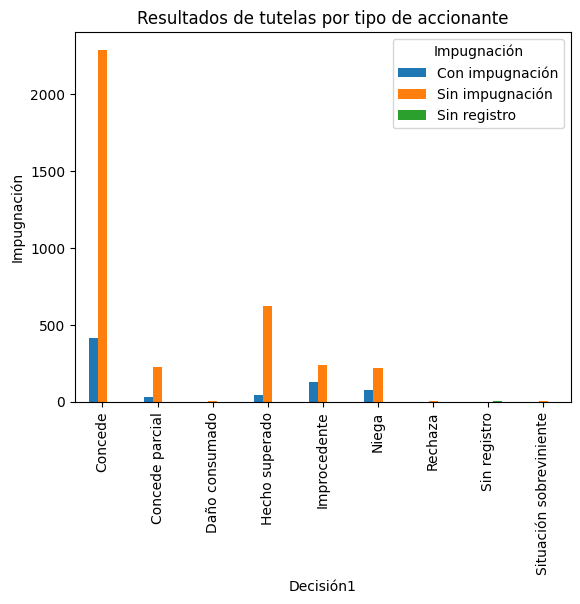

In [15]:
#Gráfica de la crosstab Decisión - Impugnación
tablac1 = pd.crosstab(df_tutelas['Decisión1'], df_tutelas['Impugnación'])
tablac1.plot(kind="bar")

plt.title("Resultados de tutelas por tipo de accionante")
plt.ylabel("Impugnación")
plt.xlabel("Decisión1")

plt.show()

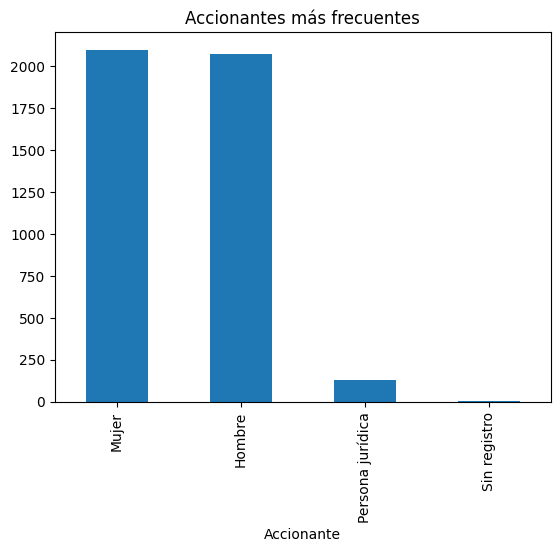

In [16]:
#Gráfico de accionantes
df_tutelas['Accionante'].value_counts().head(10).plot(kind='bar')

plt.title("Accionantes más frecuentes")
plt.show()

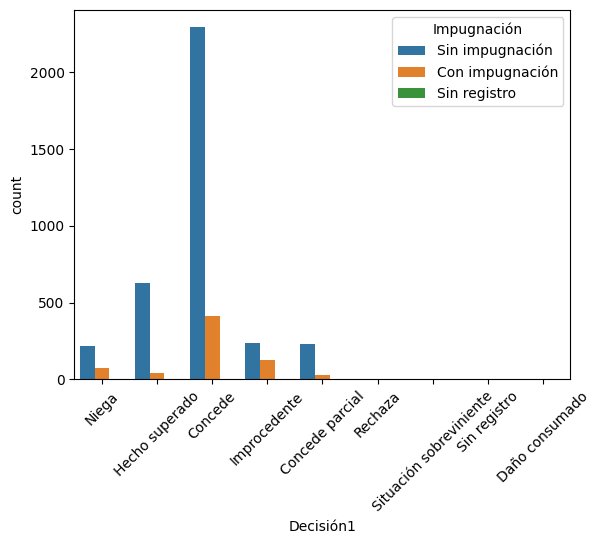

In [17]:
#gráfica de impugnación
sns.countplot( x='Decisión1', hue='Impugnación', data=df_tutelas)

plt.xticks(rotation=45)
plt.show()

In [18]:
df_tutelas[df_tutelas['Decisión1'] == 'sin registro'].index

Index([], dtype='int64')

In [19]:
#MODELO DE REGRESIÓN LINEAL

#Para poder aplicar los modelos vistos, se deben codificar las variables categóricas, en este caso tanto
# "Decisión1" e "Impugnación"
#1. Creamos copia de base de datos donde se contienen las variables categorizadas
df_tutelas_cat = df_tutelas.copy()

In [20]:
#2.1 Codificamos las variables
#Codificar Decisión1
label = LabelEncoder()
df_tutelas_cat['Decision1_cod'] = label.fit_transform(df_tutelas_cat['Decisión1'])
print(dict(zip(label.classes_, label.transform(label.classes_))))

{'Concede': np.int64(0), 'Concede parcial': np.int64(1), 'Daño consumado': np.int64(2), 'Hecho superado': np.int64(3), 'Improcedente': np.int64(4), 'Niega': np.int64(5), 'Rechaza': np.int64(6), 'Sin registro': np.int64(7), 'Situación sobreviniente': np.int64(8)}


In [21]:
#2.2Eliminamos el sin registro antes de codificar la variable
#df_tutelas_cat = df_tutelas_cat[df_tutelas_cat['Impugnación'].isin([
   # 'Sin impugnación',
    #'Con impugnación'
#])]

In [22]:
#2.2 Codificar Impugnación
label = LabelEncoder()
df_tutelas_cat['Impugnación_cod'] = label.fit_transform(df_tutelas_cat['Impugnación'])
print(dict(zip(label.classes_, label.transform(label.classes_))))

{'Con impugnación': np.int64(0), 'Sin impugnación': np.int64(1), 'Sin registro': np.int64(2)}


In [23]:
#3. Creamos un dataset con las variables a estudiar
df_tutelas_reg = df_tutelas_cat[['Decision1_cod', 'Impugnación_cod']]
df_tutelas_reg

,Decision1_cod,Impugnación_cod
0,5,1
1,3,1
2,5,1
3,0,0
4,5,1
...,...,...
4298,0,1
4299,5,1
4300,0,1
4301,0,1


In [24]:
#4. Matriz de correlación
df_tutelas_reg.corr()

,Decision1_cod,Impugnación_cod
Decision1_cod,1.000000,-0.068325
Impugnación_cod,-0.068325,1.000000


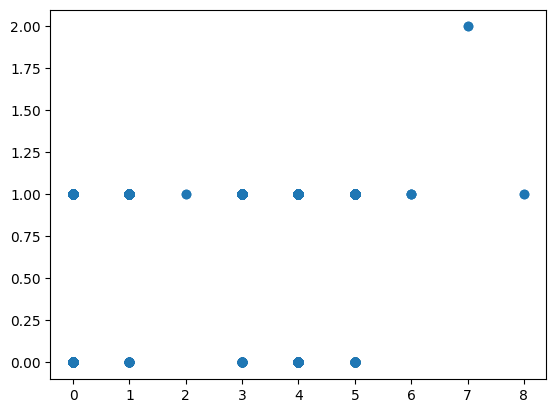

In [25]:
#5. Gráfica de las variables
#Etiqueta Y = Impugnación
plt.scatter(df_tutelas_reg['Decision1_cod'],df_tutelas_reg['Impugnación_cod'])
plt.show()

In [26]:
#6. Seleccionamos x y y, preprocesamos las variables

#6.1
x=df_tutelas_reg['Decision1_cod'].values.reshape(-1,1) #Queda los datos en 1 columna y n filas
x

array([[5],
       [3],
       [5],
       ...,
       [0],
       [0],
       [3]])

In [27]:
#6.2
y=df_tutelas_reg['Impugnación_cod'].values #Array con los valores de la columna
y

array([1, 1, 1, ..., 1, 1, 1])

In [28]:
#7. Dividir los datos en datos de entrenamiento y datos de testeo

#7.1
x_train, x_test, y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [29]:
#7.2
x_train
x_test

array([[0],
       [5],
       [5],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [1],
       [0],
       [0],
       [0],
       [3],
       [1],
       [3],
       [0],
       [1],
       [0],
       [5],
       [1],
       [3],
       [5],
       [3],
       [4],
       [0],
       [4],
       [0],
       [0],
       [0],
       [0],
       [5],
       [5],
       [0],
       [5],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [0],
       [3],
       [0],
       [0],
       [4],
       [4],
       [0],
       [3],
       [0],
       [3],
       [0],
       [4],
       [0],
       [4],
       [0],
       [3],
       [5],
       [1],
       [3],
       [5],
       [1],
       [0],
       [0],
       [0],
       [3],
       [0],
       [0],
       [0],
       [3],
       [0],
       [4],
       [5],
    

In [30]:
#8. Aplicar el modelo
modelo=LinearRegression() #Crear modelo de tipo LinearRegression
modelo.fit(x_train,y_train) #entrenando el modelo

LinearRegression()

In [31]:
#9. Ecuación modelo
modelo.intercept_ #Intercepto
print("Intercepto: ", round(modelo.intercept_,2))
modelo.coef_[0] #Coeficiente de x - pendiente
print("Coeficiente X: ", round(modelo.coef_[0],2))
print(f"Ecuacion: Y={round(modelo.coef_[0],2)}x + {round(modelo.intercept_,2)}")

Intercepto:  0.86
Coeficiente X:  -0.01
Ecuacion: Y=-0.01x + 0.86


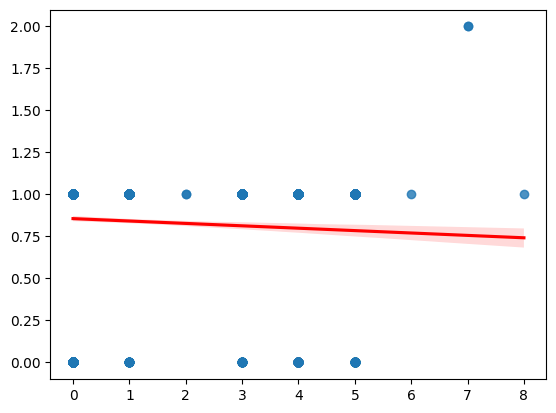

In [32]:
#10. Gráfica
sns.regplot(x=x_train,y=y_train,ci=95, line_kws={"color":"red"})
plt.show()

In [33]:
#11. Predicción
y_prediccion=modelo.predict(x_test)
y_prediccion
print(f"Predicciones {y_prediccion}")
print(f"Valor Real: {y_test}")

Predicciones [0.85628365 0.78497356 0.78497356 0.85628365 0.85628365 0.85628365
 0.85628365 0.85628365 0.85628365 0.85628365 0.85628365 0.85628365
 0.85628365 0.84202164 0.85628365 0.85628365 0.85628365 0.8134976
 0.84202164 0.8134976  0.85628365 0.84202164 0.85628365 0.78497356
 0.84202164 0.8134976  0.78497356 0.8134976  0.79923558 0.85628365
 0.79923558 0.85628365 0.85628365 0.85628365 0.85628365 0.78497356
 0.78497356 0.85628365 0.78497356 0.85628365 0.85628365 0.85628365
 0.85628365 0.85628365 0.85628365 0.85628365 0.85628365 0.85628365
 0.85628365 0.85628365 0.85628365 0.85628365 0.8134976  0.85628365
 0.85628365 0.79923558 0.79923558 0.85628365 0.8134976  0.85628365
 0.8134976  0.85628365 0.79923558 0.85628365 0.79923558 0.85628365
 0.8134976  0.78497356 0.84202164 0.8134976  0.78497356 0.84202164
 0.85628365 0.85628365 0.85628365 0.8134976  0.85628365 0.85628365
 0.85628365 0.8134976  0.85628365 0.79923558 0.78497356 0.85628365
 0.85628365 0.85628365 0.85628365 0.8134976  0.813

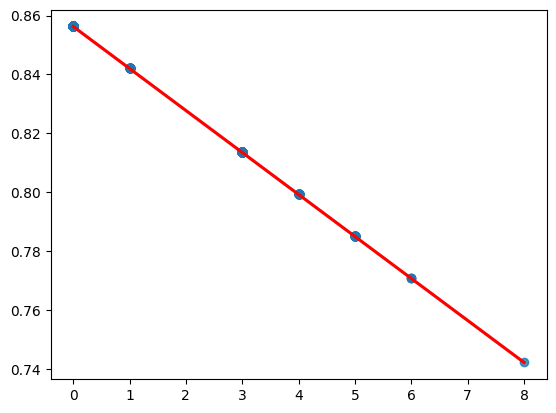

In [34]:
#11.1 Xtest vs Ypred
sns.regplot(x=x_test,y=y_prediccion,ci=95, line_kws={"color":"red"})
plt.show()

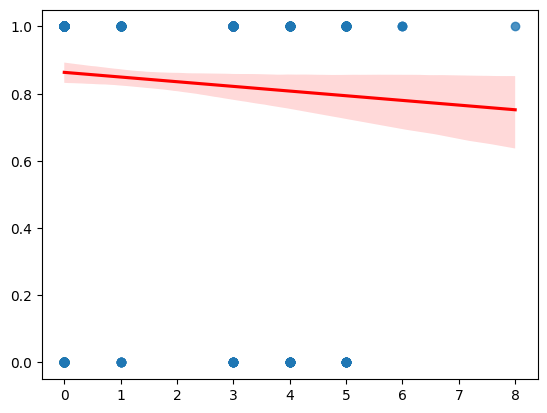

In [35]:
#11.2 Xtest vs Ytest
sns.regplot(x=x_test,y=y_test,ci=95, line_kws={"color":"red"})
plt.show()

In [36]:
#12. Evaluar el modelo

evalua_1=modelo.score(x_test,y_test) #0-1
print("Exactitud: ",evalua_1)

#Error cuadratico medio
r2=r2_score(y_test,y_prediccion)
print("r2: ",r2)

mse=mean_squared_error(y_test,y_prediccion)
print("MSE: ",mse)

R_mse=np.sqrt(mse)
print("RMSE: ",R_mse)

Exactitud:  0.004287513149887401
r2:  0.004287513149887401
MSE:  0.12924957094782505
RMSE:  0.359512963532367


In [37]:
#MODELO RANDOM FOREST REGRESSION

#1. Preparar datos
Y_rfr = df_tutelas_cat['Impugnación']
X_rfr = df_tutelas_cat.drop(columns=['Impugnación'])
df_tutelas_cat = df_tutelas_cat[~df_tutelas.isin(['sin registro']).any(axis=1)]


In [38]:
df_tutelas_cat = df_tutelas_cat.drop(columns=['Municipio'])
df_tutelas_cat = df_tutelas_cat.drop(columns=['Departamento'])
X_rfr = pd.get_dummies(X_rfr, drop_first=True)
Y_rfr = pd.get_dummies(Y_rfr, drop_first=True)

In [39]:
#2. Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_rfr, Y_rfr, test_size=0.2, random_state=42
)

In [40]:
#3. Crear el modelo Random Forest
modelo = RandomForestRegressor(
    n_estimators=120,     # número de árboles
    max_depth=12,         # profundidad máxima
    random_state=42,
    bootstrap=True, #Muestreo aleatorio con reemplazo
    #max_samples=2/3, #Muestra por cada arbol
    max_features=4
)

modelo.fit(X_train, y_train) #Entrenando

RandomForestRegressor(max_depth=12, max_features=4, n_estimators=120,
                      random_state=42)

In [41]:
#4. Predicciones
y_pred = modelo.predict(X_test)
print(y_pred)
print(y_test)

[[1. 0.]
 [1. 0.]
 [1. 0.]
 ...
 [1. 0.]
 [0. 0.]
 [1. 0.]]
      Sin impugnación  Sin registro
274              True         False
1024             True         False
807              True         False
3452             True         False
2409             True         False
...               ...           ...
2604             True         False
415              True         False
353              True         False
1299            False         False
2743             True         False

[861 rows x 2 columns]


In [43]:
y_pred = modelo.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

ValueError: Classification metrics can't handle a mix of multilabel-indicator and continuous-multioutput targets

In [49]:
#5. evaluacion

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2:", r2)

ValueError: could not convert string to float: 'Sin impugnación'

In [ ]:
#6. Gráfica
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Valor real")
plt.ylabel("Predicción")
plt.title("Real vs Predicho")
plt.plot([y.min(), y.max()], [y.min(), y.max()])  # línea ideal
plt.show()

In [ ]:
7. #Importancia de variables
importancias = pd.Series(modelo.feature_importances_, index=X_rfr.columns)
importancias.sort_values(ascending=False).plot(kind='bar')
plt.title("Importancia de variables")
plt.show()

In [50]:
#MODELO RANDOM FOREST CLASSIFIER

#1. Separar variable objetivo
y = df_tutelas_cat['Impugnación']
X = df_tutelas_cat.drop(columns=['Impugnación'])

In [51]:
#2. One-hot encoding (CLAVE)
X = pd.get_dummies(X, drop_first=True)

In [52]:
#3. Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [53]:
#4. Modelo optimizado
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=200, random_state=42)

In [54]:
#5. Evaluación
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0
